# Transfer Learning

This notebook compares training a pretrained GoogLeNet model directly with freezing most layers and training only the final classifier.


In [1]:
# The small sample dataset used here is included in this repository.

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms
from torchvision import models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


### Track Model Training and Validation Metrics

To visualize the training and validation performance of both models over epochs, we'll create global dictionaries to store loss and accuracy values. We will then modify the training loops to populate these dictionaries with per-epoch metrics.

In [3]:
# Initialize dictionaries to store training and validation history for both models
googlenet_metrics = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
model_metrics = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

## Load the sample leaf dataset

A small image dataset is included so the notebook can run without Kaggle credentials.


In [4]:
train_df = pd.read_csv('bean-leaf-lesions-classification/train.csv')
val_df = pd.read_csv('bean-leaf-lesions-classification/val.csv')

train_df["image:FILE"] = "bean-leaf-lesions-classification/" + train_df["image:FILE"]
val_df["image:FILE"] = "bean-leaf-lesions-classification/" + val_df["image:FILE"]
print(train_df.shape)
train_df.head()

(72, 2)


,image:FILE,category
0,bean-leaf-lesions-classification/train/angular...,angular_leaf_spot
1,bean-leaf-lesions-classification/train/angular...,angular_leaf_spot
2,bean-leaf-lesions-classification/train/angular...,angular_leaf_spot
3,bean-leaf-lesions-classification/train/angular...,angular_leaf_spot
4,bean-leaf-lesions-classification/train/angular...,angular_leaf_spot


In [5]:
print(val_df.shape)
val_df.head()

(24, 2)


,image:FILE,category
0,bean-leaf-lesions-classification/val/angular_l...,angular_leaf_spot
1,bean-leaf-lesions-classification/val/angular_l...,angular_leaf_spot
2,bean-leaf-lesions-classification/val/angular_l...,angular_leaf_spot
3,bean-leaf-lesions-classification/val/angular_l...,angular_leaf_spot
4,bean-leaf-lesions-classification/val/angular_l...,angular_leaf_spot


In [6]:
train_df["category"].unique()

<StringArray>
['angular_leaf_spot', 'bean_rust', 'healthy']
Length: 3, dtype: str

In [7]:
print(train_df['category'].value_counts())

category
angular_leaf_spot    24
bean_rust            24
healthy              24
Name: count, dtype: int64


## Prepare image tensors

Images are resized to a fixed shape before training.


In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
label_encoder = LabelEncoder()
label_encoder.fit(train_df['category'])

class Data(Dataset):
  def __init__(self, df, transform):
    self.df = df
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(df['category']), dtype=torch.long).to(device)

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, idx):
    img_path = self.df.iloc[idx, 0]
    label = self.labels[idx]
    image = Image.open(img_path)
    if self.transform:
      image = self.transform(image).to(device)
    return image, label

train_dataset = Data(train_df, transform=transform)
val_dataset = Data(val_df, transform=transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..0.81792724].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.843908..0.8529412].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..0.81792724].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..1.0105042].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..0.83543426].


...

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..0.9754903].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..0.83543426].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..1.3584211].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..0.88795525].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..0.8004202].


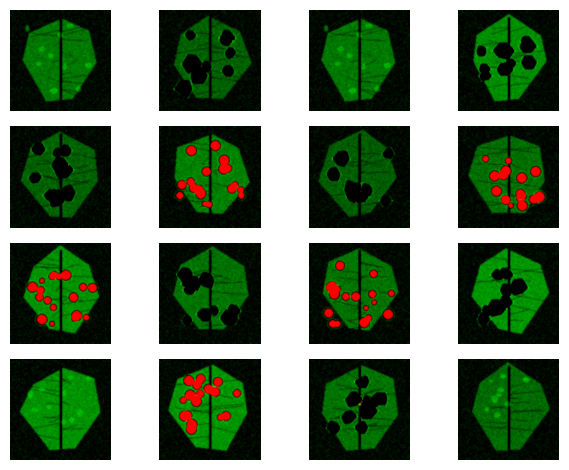

In [10]:
nrows = 4
ncols = 4

f, axarr = plt.subplots(nrows, ncols)
for row in range(nrows):
  for col in range(ncols):
    img = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
    axarr[row, col].imshow(img.permute(1, 2, 0))
    axarr[row, col].axis('off')
plt.tight_layout()
plt.show()

In [11]:
LR = 1e-3
BATCH_SIZE = 4
EPOCHS = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Train GoogLeNet

The first run updates all model parameters.


In [12]:
googlenet_model = models.googlenet(weights='DEFAULT')

In [13]:
for param in googlenet_model.parameters():
  param.requires_grad = True

In [14]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [15]:
num_classes = len(train_df['category'].unique())
num_classes

3

In [16]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(params=googlenet_model.parameters(), lr=LR)

googlenet_model = googlenet_model.to(device)

# Clear previous metrics if the cell is rerun
googlenet_metrics['train_loss'] = []
googlenet_metrics['train_acc'] = []
googlenet_metrics['val_loss'] = []
googlenet_metrics['val_acc'] = []

print("Starting training for GoogLeNet (fully trained from scratch)")
for epoch in range(EPOCHS):
  total_acc_train, total_loss_train = 0, 0
  googlenet_model.train() # Set model to training mode

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    inputs, labels = inputs.to(device), labels.to(device) # Ensure inputs/labels are on device

    outputs = googlenet_model(inputs)
    if isinstance(outputs, tuple):
        outputs = outputs.logits

    train_loss = loss_fn(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()
    optimizer.step()

    train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_train += train_acc

  avg_train_loss = total_loss_train / len(train_loader) # Average loss per batch
  avg_train_acc = total_acc_train / train_dataset.__len__() # Average accuracy per sample

  # Validation step
  googlenet_model.eval() # Set model to evaluation mode
  total_acc_val, total_loss_val = 0, 0
  with torch.inference_mode():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device) # Ensure inputs/labels are on device
      outputs = googlenet_model(inputs)
      if isinstance(outputs, tuple):
          outputs = outputs.logits
      val_loss = loss_fn(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  avg_val_loss = total_loss_val / len(val_loader)
  avg_val_acc = total_acc_val / val_dataset.__len__()

  googlenet_metrics['train_loss'].append(avg_train_loss)
  googlenet_metrics['train_acc'].append(avg_train_acc)
  googlenet_metrics['val_loss'].append(avg_val_loss)
  googlenet_metrics['val_acc'].append(avg_val_acc)

  print(f"Epoch: {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc*100:.2f}%")

print("GoogLeNet training finished.")

Starting training for GoogLeNet (fully trained from scratch)


Epoch: 1 | Train Loss: 0.3493 | Train Acc: 86.11% | Val Loss: 0.0023 | Val Acc: 100.00%


Epoch: 2 | Train Loss: 0.2656 | Train Acc: 91.67% | Val Loss: 0.0080 | Val Acc: 100.00%


Epoch: 3 | Train Loss: 0.3569 | Train Acc: 91.67% | Val Loss: 0.0605 | Val Acc: 100.00%


Epoch: 4 | Train Loss: 0.1915 | Train Acc: 91.67% | Val Loss: 0.0750 | Val Acc: 95.83%
GoogLeNet training finished.


In [18]:
with torch.inference_mode():
  total_loss_test , total_acc_test = 0, 0

  for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    preds = googlenet_model(inputs)

    acc = (torch.argmax(preds, axis=1) == labels).sum().item()
    total_acc_test += acc

    loss = loss_fn(preds, labels)
    total_loss_test += loss.item()

  print(f"Test Loss: {round(total_loss_test / val_dataset.__len__(), 4)} | Test Acc: {round(total_acc_test / val_dataset.__len__() * 100, 4)}%")

Test Loss: 0.0187 | Test Acc: 95.8333%


## Fine tune the classifier

The second run freezes the backbone and trains the final layer.


In [19]:
model = models.googlenet(weights='DEFAULT')
num_classes = 3
for param in model.parameters():
  param.requires_grad = False

model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.fc.requires_grad = True
model = model.to(device)

In [20]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(params=model.parameters(), lr=LR)

model = model.to(device)

# Clear previous metrics if the cell is rerun
model_metrics['train_loss'] = []
model_metrics['train_acc'] = []
model_metrics['val_loss'] = []
model_metrics['val_acc'] = []

print("Starting training for Fine-tuned GoogLeNet")
for epoch in range(EPOCHS):
  total_acc_train, total_loss_train = 0, 0
  model.train() # Set model to training mode

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    inputs, labels = inputs.to(device), labels.to(device) # Ensure inputs/labels are on device

    outputs = model(inputs)
    if isinstance(outputs, tuple):
        outputs = outputs.logits

    train_loss = loss_fn(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()
    optimizer.step()

    train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_train += train_acc

  avg_train_loss = total_loss_train / len(train_loader)
  avg_train_acc = total_acc_train / train_dataset.__len__()

  # Validation step
  model.eval() # Set model to evaluation mode
  total_acc_val, total_loss_val = 0, 0
  with torch.inference_mode():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device) # Ensure inputs/labels are on device
      outputs = model(inputs)
      if isinstance(outputs, tuple):
          outputs = outputs.logits
      val_loss = loss_fn(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  avg_val_loss = total_loss_val / len(val_loader)
  avg_val_acc = total_acc_val / val_dataset.__len__()

  model_metrics['train_loss'].append(avg_train_loss)
  model_metrics['train_acc'].append(avg_train_acc)
  model_metrics['val_loss'].append(avg_val_loss)
  model_metrics['val_acc'].append(avg_val_acc)

  print(f"Epoch: {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc*100:.2f}%")

print("Fine-tuned GoogLeNet training finished.")

Starting training for Fine-tuned GoogLeNet


Epoch: 1 | Train Loss: 1.0357 | Train Acc: 38.89% | Val Loss: 0.6960 | Val Acc: 70.83%


Epoch: 2 | Train Loss: 0.7058 | Train Acc: 79.17% | Val Loss: 0.4162 | Val Acc: 100.00%


Epoch: 3 | Train Loss: 0.5840 | Train Acc: 79.17% | Val Loss: 0.2297 | Val Acc: 100.00%


Epoch: 4 | Train Loss: 0.4384 | Train Acc: 84.72% | Val Loss: 0.1542 | Val Acc: 100.00%
Fine-tuned GoogLeNet training finished.


In [21]:
with torch.inference_mode():
  total_loss_test , total_acc_test = 0, 0

  for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    inputs, labels = inputs.to(device), labels.to(device)
    preds = model(inputs)

    acc = (torch.argmax(preds, axis=1) == labels).sum().item()
    total_acc_test += acc

    loss = loss_fn(preds, labels)
    total_loss_test += loss.item()

  print(f"Test Loss: {round(total_loss_test / val_dataset.__len__(), 4)} | Test Acc: {round(total_acc_test / val_dataset.__len__() * 100, 4)}%")

Test Loss: 0.0386 | Test Acc: 100.0%


### Training and Validation Metrics Comparison

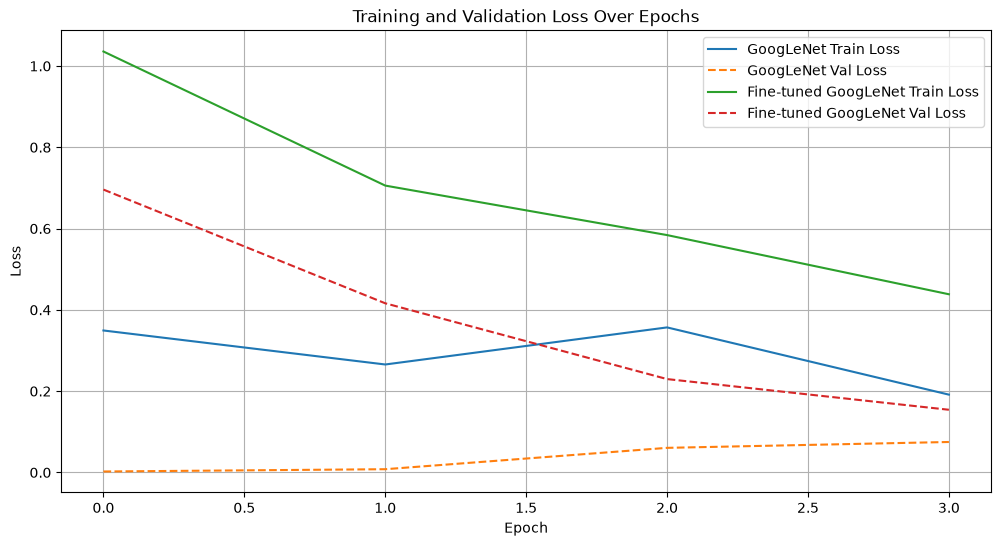

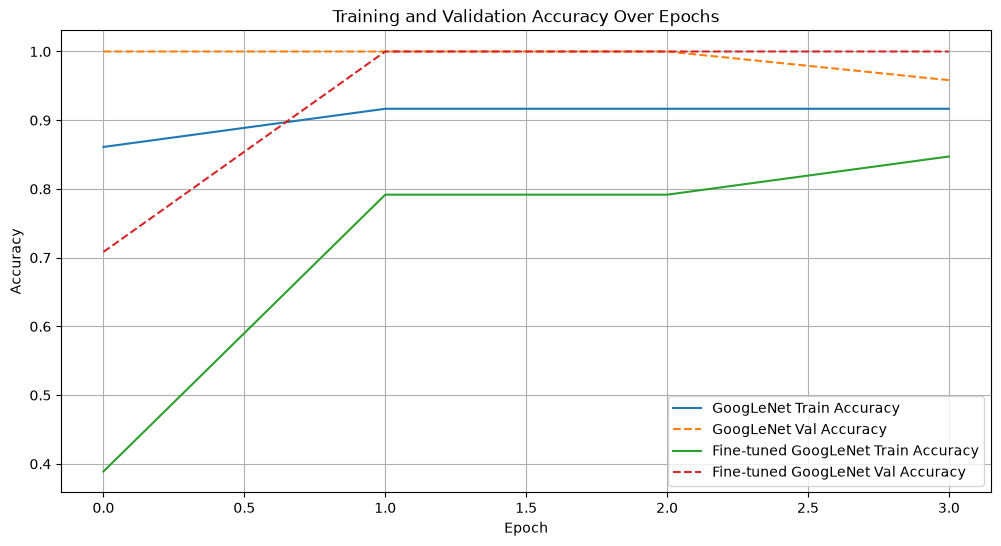

In [22]:
# Plotting Loss
plt.figure(figsize=(12, 6))
plt.plot(googlenet_metrics['train_loss'], label='GoogLeNet Train Loss')
plt.plot(googlenet_metrics['val_loss'], label='GoogLeNet Val Loss', linestyle='--')
plt.plot(model_metrics['train_loss'], label='Fine-tuned GoogLeNet Train Loss')
plt.plot(model_metrics['val_loss'], label='Fine-tuned GoogLeNet Val Loss', linestyle='--')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Accuracy
plt.figure(figsize=(12, 6))
plt.plot(googlenet_metrics['train_acc'], label='GoogLeNet Train Accuracy')
plt.plot(googlenet_metrics['val_acc'], label='GoogLeNet Val Accuracy', linestyle='--')
plt.plot(model_metrics['train_acc'], label='Fine-tuned GoogLeNet Train Accuracy')
plt.plot(model_metrics['val_acc'], label='Fine-tuned GoogLeNet Val Accuracy', linestyle='--')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()